# 🎬 Sistemas de Recomendação na Prática

**Aula de Aprendizado Não Supervisionado — Machine Learning**

---

### 📚 Roteiro da aula

1. **Fundamentos** — matriz usuário-item e esparsidade
2. **Filtragem Colaborativa**
   - User-based (baseada em usuários)
   - Item-based (baseada em itens)
   - Fatoração de matrizes (SVD)
3. **Filtragem Baseada em Conteúdo** (content-based)
4. **Modelos Híbridos**
5. **O problema do Cold Start** (partida a frio)
6. **🎯 Exercício final**

---

> ✅ **Sem dor de cabeça com instalação!** Este notebook usa apenas **NumPy, pandas, scikit-learn e matplotlib** — todas já vêm instaladas no Google Colab. Não precisa instalar nada nem reiniciar a sessão. É só ir rodando as células de cima para baixo.

> 💡 **Por que isso é "não supervisionado"?** Não temos um "rótulo correto" universal. Buscamos **estrutura latente** nos dados (gostos parecidos, itens parecidos) para prever preferências. A fatoração de matrizes (SVD), em particular, é prima próxima do PCA.

> 🔍 **Vantagem extra:** como vamos implementar os algoritmos "na mão", você vai entender exatamente **como cada técnica funciona por dentro** — não é só chamar uma função de caixa-preta.


## 🔧 Setup — importando as bibliotecas

Tudo que precisamos já está no Colab. Basta importar.


In [53]:
import numpy as np                 # operações numéricas e álgebra linear
import pandas as pd                # manipulação de tabelas (DataFrames)
import matplotlib.pyplot as plt    # gráficos
import seaborn as sns              # mapas de calor e gráficos estatísticos

# scikit-learn — nossas ferramentas principais
from sklearn.metrics.pairwise import cosine_similarity   # similaridade de cosseno
from sklearn.decomposition import TruncatedSVD            # fatoração de matrizes (SVD)
from sklearn.feature_extraction.text import TfidfVectorizer  # vetorizar texto/gêneros

# Configurações
sns.set_style('whitegrid')
np.random.seed(42)  # garante que todos tenham os mesmos resultados

print("✅ Bibliotecas importadas! NumPy:", np.__version__)

✅ Bibliotecas importadas! NumPy: 2.0.0


---
# 📊 Parte 1 — Fundamentos e a matriz usuário-item

A peça central de qualquer sistema de recomendação é a **matriz de interações** (ou matriz usuário-item):

|         | Filme A | Filme B | Filme C | Filme D |
|---------|:-------:|:-------:|:-------:|:-------:|
| **Ana** |    5    |    ?    |    3    |    ?    |
| **Bia** |    ?    |    4    |    ?    |    2    |
| **Caio**|    4    |    ?    |    5    |    ?    |

- As **linhas** são usuários, as **colunas** são itens, e as **células** são as avaliações (ratings).
- A maioria das células está **vazia** (`?`) — chamamos isso de **esparsidade**. Em sistemas reais, mais de 99% das células costumam estar vazias!
- 🎯 **O objetivo do sistema de recomendação é prever os valores das células vazias.**

### Tipos de feedback
- **Explícito**: o usuário dá uma nota direta (estrelas, like/dislike) — é o que usaremos aqui.
- **Implícito**: inferimos preferência pelo comportamento (cliques, compras, tempo assistido).


### 🎲 Criando nosso dataset

Vamos **gerar um dataset sintético realista**: cada usuário tem afinidade por alguns gêneros, e suas notas refletem isso (com algum ruído). Assim, os padrões que os algoritmos vão descobrir são *de verdade* — e podemos checar se as recomendações fazem sentido comparando com as preferências que nós mesmos criamos.

> 💡 Quer usar dados reais depois? O **MovieLens** (https://grouplens.org/datasets/movielens/) tem o mesmo formato (`user_id, movie_id, rating`) e todo o código abaixo funciona direto com ele.


In [54]:
# ===== Catálogo de filmes com nomes reais =====
filmes_dados = [
    (1,  'Batman: O Cavaleiro das Trevas',     'Ação|Thriller|Drama'),
    (2,  'Inception - A Origem',               'Ficção|Ação|Thriller'),
    (3,  'Um Sonho de Liberdade',              'Drama'),
    (4,  'Pulp Fiction',                       'Thriller|Drama'),
    (5,  'O Poderoso Chefão',                  'Drama|Thriller'),
    (6,  'A Lista de Schindler',               'Drama'),
    (7,  'Forrest Gump',                       'Drama|Romance'),
    (8,  'Matrix',                             'Ficção|Ação'),
    (9,  'Clube da Luta',                      'Thriller|Drama'),
    (10, 'O Silêncio dos Inocentes',           'Thriller|Terror'),
    (11, 'Interestelar',                       'Ficção|Aventura|Drama'),
    (12, 'Gladiador',                          'Ação|Aventura|Drama'),
    (13, 'O Rei Leão',                         'Animação|Aventura|Drama'),
    (14, 'Toy Story',                          'Animação|Aventura|Comédia'),
    (15, 'Vingadores: Ultimato',               'Ação|Aventura|Ficção'),
    (16, 'Homem de Ferro',                     'Ação|Aventura|Ficção'),
    (17, 'Homem-Aranha',                       'Ação|Aventura'),
    (18, 'Jurassic Park',                      'Aventura|Ficção|Terror'),
    (19, 'Star Wars: Uma Nova Esperança',      'Ação|Aventura|Ficção'),
    (20, 'Indiana Jones e a Arca Perdida',     'Ação|Aventura'),
    (21, 'De Volta para o Futuro',             'Aventura|Comédia|Ficção'),
    (22, 'E.T. o Extra-Terrestre',             'Aventura|Ficção|Drama'),
    (23, 'Esqueceram de Mim',                  'Comédia'),
    (24, 'Se Beber, Não Case!',                'Comédia'),
    (25, 'Missão Madrinha de Casamento',       'Comédia|Romance'),
    (26, 'Titanic',                            'Drama|Romance'),
    (27, 'La La Land',                         'Drama|Romance|Comédia'),
    (28, 'O Diário de uma Paixão',             'Drama|Romance'),
    (29, 'Uma Linda Mulher',                   'Comédia|Romance'),
    (30, 'Notting Hill',                       'Comédia|Romance'),
    (31, 'A Hora do Pesadelo',                 'Terror'),
    (32, 'O Exorcista',                        'Terror|Thriller'),
    (33, 'Corra!',                             'Terror|Thriller'),
    (34, 'Parasita',                           'Thriller|Drama'),
    (35, 'Entre Facas e Segredos',             'Thriller|Comédia|Drama'),
    (36, 'Se7en - Os Sete Crimes',             'Thriller|Drama'),
    (37, 'A Marcha dos Pinguins',              'Documentário'),
    (38, 'Planeta Terra II',                   'Documentário|Aventura'),
    (39, 'WALL-E',                             'Animação|Ficção|Romance'),
    (40, 'Procurando Nemo',                    'Animação|Aventura|Comédia'),
]

movies_df = pd.DataFrame(filmes_dados, columns=['movie_id', 'title', 'genres'])
n_filmes = len(movies_df)
print(f"Catálogo com {n_filmes} filmes reais. Amostra:")
movies_df.head()

Catálogo com 40 filmes reais. Amostra:


,movie_id,title,genres
0,1,Batman: O Cavaleiro das Trevas,Ação|Thriller|Drama
1,2,Inception - A Origem,Ficção|Ação|Thriller
2,3,Um Sonho de Liberdade,Drama
3,4,Pulp Fiction,Thriller|Drama
4,5,O Poderoso Chefão,Drama|Thriller


In [55]:
# ===== Usuários e suas avaliações =====
n_users = 150

# Cada usuário tem uma "preferência latente": gosta de 2-3 gêneros.
# É essa estrutura escondida que os algoritmos vão tentar redescobrir!
user_prefs = {}
for u in range(1, n_users + 1):
    prefs = np.random.choice(generos_pool, size=np.random.randint(2, 4), replace=False)
    user_prefs[u] = set(prefs)

# Gera avaliações coerentes com as preferências
ratings = []
for _ in range(6000):
    u = np.random.randint(1, n_users + 1)
    m = np.random.randint(1, n_filmes + 1)

    movie_genres = set(movies_df.iloc[m - 1]['genres'].split('|'))
    overlap = len(user_prefs[u] & movie_genres)  # gêneros em comum

    # Nota base: cresce com a afinidade. + ruído gaussiano para realismo.
    nota = 2.3 + overlap * 1.3 + np.random.normal(0, 0.5)
    nota = int(np.clip(round(nota), 1, 5))   # arredonda e limita entre 1 e 5

    ratings.append({'user_id': u, 'movie_id': m, 'rating': nota})

# Remove duplicatas (mesmo usuário avaliou o mesmo filme mais de uma vez)
ratings_df = pd.DataFrame(ratings).drop_duplicates(
    subset=['user_id', 'movie_id']).reset_index(drop=True)

print(f"Total de avaliações únicas: {len(ratings_df)}")
print(f"Usuários: {ratings_df['user_id'].nunique()} | Filmes: {ratings_df['movie_id'].nunique()}")
ratings_df.head()

Total de avaliações únicas: 3792
Usuários: 150 | Filmes: 40


,user_id,movie_id,rating
0,53,7,3
1,122,2,2
2,54,1,4
3,26,29,2
4,149,11,3


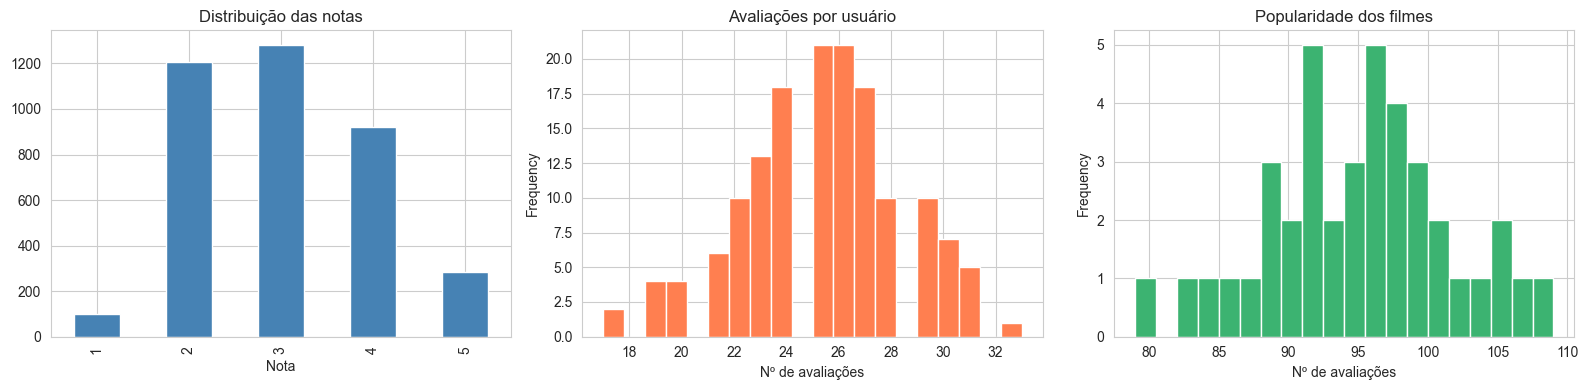

Esparsidade: 36.8% das células da matriz estão vazias


In [56]:
# ===== Análise exploratória =====
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ratings_df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição das notas'); axes[0].set_xlabel('Nota')

ratings_df.groupby('user_id').size().plot(
    kind='hist', bins=20, ax=axes[1], color='coral')
axes[1].set_title('Avaliações por usuário'); axes[1].set_xlabel('Nº de avaliações')

ratings_df.groupby('movie_id').size().plot(
    kind='hist', bins=20, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Popularidade dos filmes'); axes[2].set_xlabel('Nº de avaliações')

plt.tight_layout(); plt.show()

# Esparsidade
n_possiveis = ratings_df['user_id'].nunique() * ratings_df['movie_id'].nunique()
sparsity = 100 * (1 - len(ratings_df) / n_possiveis)
print(f"Esparsidade: {sparsity:.1f}% das células da matriz estão vazias")

Formato da matriz: 150 usuários x 40 filmes


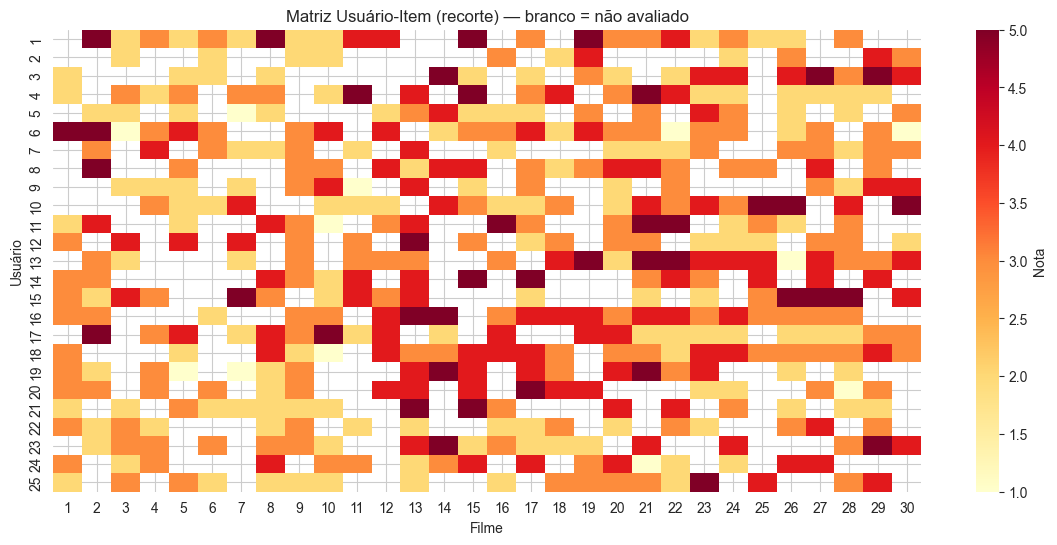

In [57]:
# ===== Construindo a matriz usuário-item =====
# pivot_table transforma o formato "longo" (1 linha por avaliação)
# em matriz (linhas = usuários, colunas = filmes). Células vazias viram NaN.
matriz = ratings_df.pivot_table(index='user_id', columns='movie_id', values='rating')

print(f"Formato da matriz: {matriz.shape[0]} usuários x {matriz.shape[1]} filmes")

# Visualiza um recorte como mapa de calor (branco = não avaliado)
plt.figure(figsize=(14, 6))
sns.heatmap(matriz.iloc[:25, :30], cmap='YlOrRd', cbar_kws={'label': 'Nota'})
plt.title('Matriz Usuário-Item (recorte) — branco = não avaliado')
plt.xlabel('Filme'); plt.ylabel('Usuário')
plt.show()

### ✂️ Separando treino e teste

Para avaliar honestamente nossos modelos, separamos 25% das avaliações para **teste**. O modelo só "vê" as de treino; depois medimos o erro nas de teste (que ele nunca viu).

A métrica que usaremos é o **RMSE** (Root Mean Squared Error): a raiz da média dos erros ao quadrado. Quanto **menor**, melhor.


In [58]:
# Embaralha e divide as avaliações
shuffled = ratings_df.sample(frac=1, random_state=42).reset_index(drop=True)
n_test = int(0.25 * len(shuffled))

test_df  = shuffled.iloc[:n_test].reset_index(drop=True)   # 25% para teste
train_df = shuffled.iloc[n_test:].reset_index(drop=True)   # 75% para treino

print(f"Treino: {len(train_df)} avaliações | Teste: {len(test_df)} avaliações")

# Constrói a matriz APENAS com os dados de treino
R = train_df.pivot_table(index='user_id', columns='movie_id', values='rating')

# Listas e dicionários de mapeamento (id -> posição na matriz) — usaremos muito
user_ids = R.index.tolist()
item_ids = R.columns.tolist()
u_idx = {u: i for i, u in enumerate(user_ids)}   # user_id  -> linha
i_idx = {m: i for i, m in enumerate(item_ids)}   # movie_id -> coluna

# Média global das notas (usada como "chute" padrão quando não há info)
global_mean = train_df['rating'].mean()

# Valores brutos da matriz (com NaN nas células vazias)
R_values = R.values

print(f"Matriz de treino: {R.shape}")
print(f"Média global das notas: {global_mean:.3f}")

Treino: 2844 avaliações | Teste: 948 avaliações
Matriz de treino: (150, 40)
Média global das notas: 3.038


### 📏 Função de avaliação (RMSE)

Vamos criar uma função que recebe um "preditor" (uma função que estima a nota de um par usuário-filme) e calcula o RMSE no conjunto de teste. Assim podemos comparar todos os métodos de forma justa.


In [59]:
def avaliar_rmse(funcao_pred):
    """
    Calcula o RMSE de um preditor no conjunto de teste.

    Args:
        funcao_pred: função que recebe (user_id, movie_id) e retorna a nota estimada
    Returns:
        valor do RMSE (float)
    """
    erros = []
    for _, linha in test_df.iterrows():
        pred = funcao_pred(linha['user_id'], linha['movie_id'])
        pred = np.clip(pred, 1, 5)               # garante que fica na escala [1, 5]
        erros.append((pred - linha['rating']) ** 2)
    return np.sqrt(np.mean(erros))


# Baseline (linha de base): sempre chutar a média global.
# Qualquer modelo decente PRECISA ser melhor que isso!
rmse_baseline = avaliar_rmse(lambda u, m: global_mean)
print(f"📊 RMSE do baseline (chutar sempre a média): {rmse_baseline:.4f}")
print("   → Nossos modelos precisam ficar ABAIXO desse valor.")

📊 RMSE do baseline (chutar sempre a média): 0.9615
   → Nossos modelos precisam ficar ABAIXO desse valor.


---
# 🤝 Parte 2 — Filtragem Colaborativa

A **filtragem colaborativa** se baseia numa ideia simples e poderosa:

> *"Pessoas que concordaram no passado tendem a concordar no futuro."*

Ela **não olha o conteúdo** dos itens — só o **padrão de interações**. Duas grandes famílias:

1. **Baseada em vizinhança** (KNN): encontra usuários ou itens parecidos
   - **User-based**: "usuários parecidos com você gostaram disso"
   - **Item-based**: "quem gostou desse item também gostou daquele"
2. **Baseada em modelo**: aprende fatores latentes (**SVD** / fatoração de matrizes)


## 👥 2.1 — Filtragem Colaborativa User-Based

**Ideia:** para prever a nota que a Ana daria ao Filme X:
1. Encontramos os usuários **mais parecidos com a Ana** (os "vizinhos")
2. Olhamos as notas que esses vizinhos deram ao Filme X
3. Fazemos uma **média ponderada** pela similaridade

### Detalhe importante: centralizar pela média do usuário

Alguns usuários são "generosos" (dão notas altas pra tudo) e outros são "rígidos". Para comparar de forma justa, **subtraímos a média de cada usuário** antes de calcular a similaridade. Trabalhamos com o *desvio* da média, não com a nota bruta.

A similaridade entre usuários é medida pelo **cosseno** dos vetores de notas centralizadas.


In [60]:
# ===== Pré-cálculo para o user-based =====

# Média de cada usuário (ignorando NaN automaticamente)
user_means = R.mean(axis=1)

# Centraliza: subtrai a média do usuário de cada nota dele.
# Células vazias (NaN) viram 0 = "neutro" (nem acima nem abaixo da média).
R_centered_user = R.sub(user_means, axis=0).fillna(0)

# Matriz de similaridade usuário-usuário (cosseno).
# Resultado: matriz n_users x n_users.
user_sim = cosine_similarity(R_centered_user)

print(f"Matriz de similaridade entre usuários: {user_sim.shape}")

Matriz de similaridade entre usuários: (150, 150)


In [61]:
def prever_user_based(user_id, movie_id, k=30):
    """
    Prevê a nota de (user_id, movie_id) usando os k usuários mais parecidos
    que avaliaram esse filme.
    """
    # Se nunca vimos o usuário ou o filme no treino → cold start → usa a média global
    if user_id not in u_idx or movie_id not in i_idx:
        return global_mean

    ui = u_idx[user_id]    # linha do usuário-alvo
    mi = i_idx[movie_id]   # coluna do filme-alvo

    # Notas que TODOS os usuários deram a este filme (com NaN onde não avaliaram)
    coluna_filme = R_values[:, mi]
    avaliaram = ~np.isnan(coluna_filme)   # máscara: quem avaliou o filme

    # Similaridades do alvo com todos; zera a si mesmo e quem não avaliou o filme
    sims = user_sim[ui].copy()
    sims[ui] = 0
    sims = np.where(avaliaram, sims, 0)

    # Pega os k vizinhos de maior similaridade (em valor absoluto)
    vizinhos = np.argsort(np.abs(sims))[::-1][:k]
    vizinhos = vizinhos[sims[vizinhos] != 0]   # mantém só vizinhos válidos

    # Sem vizinhos úteis → devolve a média do próprio usuário
    if len(vizinhos) == 0:
        return user_means.values[ui]

    # Média ponderada dos DESVIOS dos vizinhos (nota - média do vizinho)
    desvios = coluna_filme[vizinhos] - user_means.values[vizinhos]
    numerador = np.sum(sims[vizinhos] * desvios)
    denominador = np.sum(np.abs(sims[vizinhos]))

    # Previsão = média do alvo + ajuste vindo dos vizinhos
    return user_means.values[ui] + (numerador / denominador if denominador > 0 else 0)


# Avalia
rmse_user = avaliar_rmse(prever_user_based)
print(f"📊 User-based KNN — RMSE: {rmse_user:.4f}  (baseline: {rmse_baseline:.4f})")

📊 User-based KNN — RMSE: 0.8566  (baseline: 0.9615)


## 🎯 2.2 — Filtragem Colaborativa Item-Based

**Ideia:** em vez de comparar usuários, comparamos **itens**. Para prever a nota da Ana para o Filme X, olhamos os filmes **parecidos com o X** que a Ana já avaliou.

**Por que item-based costuma ser melhor na prática?**
- 🏢 **Itens mudam menos que usuários** → a matriz de similaridade item-item é estável e pode ser pré-computada
- ⚡ Geralmente há menos itens do que usuários (mais escalável)
- 🛒 Foi a base do sistema da Amazon ("quem comprou isso também comprou...")

A estrutura é **espelhada** em relação ao user-based: agora centralizamos pela média de cada **item** e calculamos similaridade entre **colunas**.


In [62]:
# ===== Pré-cálculo para o item-based =====

# Média de cada FILME (por coluna)
item_means = R.mean(axis=0)

# Centraliza pela média do item e calcula similaridade item-item.
# Transpomos (.T) para que cada linha seja um filme antes do cosseno.
R_centered_item = R.sub(item_means, axis=0).fillna(0)
item_sim = cosine_similarity(R_centered_item.T)

print(f"Matriz de similaridade entre itens: {item_sim.shape}")

Matriz de similaridade entre itens: (40, 40)


In [63]:
def prever_item_based(user_id, movie_id, k=30):
    """
    Prevê a nota de (user_id, movie_id) usando os k filmes mais parecidos
    com o filme-alvo que o usuário JÁ avaliou.
    """
    if user_id not in u_idx or movie_id not in i_idx:
        return global_mean

    ui = u_idx[user_id]
    mi = i_idx[movie_id]

    # Notas que o usuário deu a TODOS os filmes (NaN onde não avaliou)
    linha_usuario = R_values[ui, :]
    avaliou = ~np.isnan(linha_usuario)   # máscara: filmes que o usuário avaliou

    # Similaridade do filme-alvo com os demais; zera a si mesmo e os não avaliados
    sims = item_sim[mi].copy()
    sims[mi] = 0
    sims = np.where(avaliou, sims, 0)

    vizinhos = np.argsort(np.abs(sims))[::-1][:k]
    vizinhos = vizinhos[sims[vizinhos] != 0]

    if len(vizinhos) == 0:
        return item_means.values[mi]

    # Média ponderada dos desvios (nota do usuário - média do filme vizinho)
    desvios = linha_usuario[vizinhos] - item_means.values[vizinhos]
    numerador = np.sum(sims[vizinhos] * desvios)
    denominador = np.sum(np.abs(sims[vizinhos]))

    return item_means.values[mi] + (numerador / denominador if denominador > 0 else 0)


rmse_item = avaliar_rmse(prever_item_based)
print(f"📊 Item-based KNN — RMSE: {rmse_item:.4f}  (baseline: {rmse_baseline:.4f})")

📊 Item-based KNN — RMSE: 0.8495  (baseline: 0.9615)


## 🧮 2.3 — Fatoração de Matrizes (SVD)

Aqui está a parte mais "não supervisionada" e elegante. A ideia da **fatoração de matrizes** é decompor a matriz usuário-item gigante em duas matrizes menores de **fatores latentes**:

$$R \approx U \times V^T$$

- $U$: cada usuário vira um vetor de $k$ fatores latentes
- $V$: cada item vira um vetor de $k$ fatores latentes
- A nota prevista é o **produto escalar** entre o vetor do usuário e o do item

**O que são esses "fatores latentes"?** São dimensões abstratas descobertas automaticamente — podem capturar coisas como "quão ação é o filme" ou "quanto o usuário gosta de comédia", **sem ninguém ter rotulado isso**. É a mesma intuição do PCA!

Usamos o `TruncatedSVD` do scikit-learn, que é justamente a técnica que ficou famosa no **Prêmio Netflix**.


In [64]:
# ===== Treinando o SVD =====

# Centralizamos pela média do usuário (mesma lógica do user-based).
# O SVD vai modelar os DESVIOS em relação à média de cada usuário.
R_svd = R.sub(user_means, axis=0).fillna(0)

# n_components = número de fatores latentes (dimensões do espaço aprendido)
svd = TruncatedSVD(n_components=15, random_state=42)

# U: representação dos usuários no espaço latente (n_users x 15)
U = svd.fit_transform(R_svd)
# Vt: representação dos itens no espaço latente (15 x n_items)
Vt = svd.components_

# Reconstrói a matriz completa: produto das matrizes + devolve a média do usuário
R_pred = np.dot(U, Vt) + user_means.values.reshape(-1, 1)

print(f"U (usuários x fatores): {U.shape}")
print(f"Vt (fatores x itens):   {Vt.shape}")
print(f"Matriz reconstruída:    {R_pred.shape}")


def prever_svd(user_id, movie_id):
    """Lê a nota prevista na matriz reconstruída pelo SVD."""
    if user_id not in u_idx or movie_id not in i_idx:
        return global_mean
    return R_pred[u_idx[user_id], i_idx[movie_id]]


rmse_svd = avaliar_rmse(prever_svd)
print(f"\n📊 SVD — RMSE: {rmse_svd:.4f}  (baseline: {rmse_baseline:.4f})")

U (usuários x fatores): (150, 15)
Vt (fatores x itens):   (15, 40)
Matriz reconstruída:    (150, 40)

📊 SVD — RMSE: 0.9132  (baseline: 0.9615)


       Algoritmo     RMSE
  Item-based KNN 0.849476
  User-based KNN 0.856578
             SVD 0.913175
Baseline (média) 0.961529


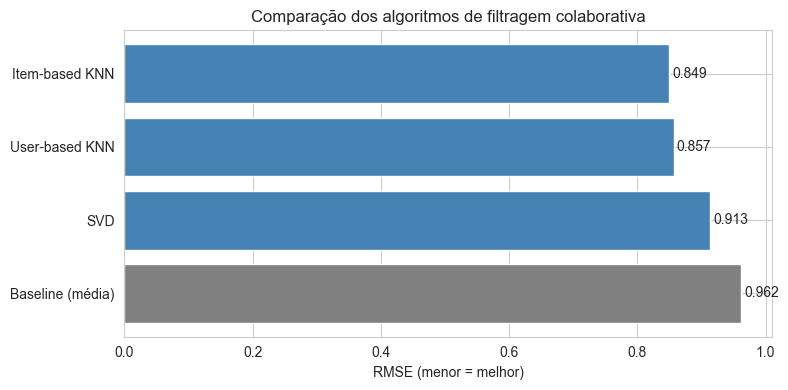

In [65]:
# ===== Comparando os três algoritmos =====
resultados = pd.DataFrame({
    'Algoritmo': ['Baseline (média)', 'User-based KNN', 'Item-based KNN', 'SVD'],
    'RMSE': [rmse_baseline, rmse_user, rmse_item, rmse_svd]
}).sort_values('RMSE')

print(resultados.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
cores = ['gray' if a == 'Baseline (média)' else 'steelblue' for a in resultados['Algoritmo']]
ax.barh(resultados['Algoritmo'], resultados['RMSE'], color=cores)
ax.set_xlabel('RMSE (menor = melhor)')
ax.set_title('Comparação dos algoritmos de filtragem colaborativa')
ax.invert_yaxis()
for i, v in enumerate(resultados['RMSE']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center')
plt.tight_layout(); plt.show()

### 🎁 Gerando recomendações Top-N de verdade

O RMSE é útil, mas no fim queremos uma **lista de filmes para recomendar**. Vamos criar uma função que prevê a nota de todos os filmes que o usuário ainda **não viu** e retorna os melhores.


In [66]:
def recomendar_top_n(funcao_pred, user_id, n=5):
    """
    Gera as Top-N recomendações para um usuário usando qualquer preditor.
    """
    # Filmes que o usuário já avaliou (não recomendamos esses de novo)
    ja_vistos = set(ratings_df[ratings_df['user_id'] == user_id]['movie_id'])

    # Prevê a nota de todos os filmes não vistos
    previsoes = []
    for movie_id in movies_df['movie_id']:
        if movie_id not in ja_vistos:
            nota = np.clip(funcao_pred(user_id, movie_id), 1, 5)
            previsoes.append((movie_id, nota))

    # Ordena pela nota prevista (decrescente) e pega os N melhores
    previsoes.sort(key=lambda x: x[1], reverse=True)
    top = previsoes[:n]

    resultado = pd.DataFrame(top, columns=['movie_id', 'nota_prevista'])
    resultado = resultado.merge(movies_df, on='movie_id')
    return resultado[['movie_id', 'title', 'genres', 'nota_prevista']]


# Exemplo: Top-5 para o usuário 1 usando SVD
usuario_exemplo = 1
print(f"🎬 Top-5 recomendações para o usuário {usuario_exemplo} (via SVD):\n")
print(recomendar_top_n(prever_svd, usuario_exemplo, n=5).to_string(index=False))

# Compara com as preferências REAIS que criamos — bate?
print(f"\n👤 Preferências reais do usuário {usuario_exemplo}: {user_prefs[usuario_exemplo]}")

🎬 Top-5 recomendações para o usuário 1 (via SVD):

 movie_id                          title                 genres  nota_prevista
       16                 Homem de Ferro   Ação|Aventura|Ficção       3.732240
        1 Batman: O Cavaleiro das Trevas    Ação|Thriller|Drama       3.413481
       35         Entre Facas e Segredos Thriller|Comédia|Drama       3.280230
       27                     La La Land  Drama|Romance|Comédia       3.070333
       18                  Jurassic Park Aventura|Ficção|Terror       2.836686

👤 Preferências reais do usuário 1: {np.str_('Ficção'), np.str_('Ação')}


---
# 📝 Parte 3 — Filtragem Baseada em Conteúdo

A **filtragem baseada em conteúdo** funciona de forma totalmente diferente da colaborativa:

> *"Se você gostou deste filme, vou recomendar outros **parecidos em conteúdo** (mesmos gêneros, diretor, atores...)."*

**Características:**
- ✅ Não precisa de outros usuários → funciona para itens novos
- ✅ Recomendações explicáveis ("recomendei porque é de Ação, como o que você curtiu")
- ❌ Tende a recomendar "mais do mesmo" (pouca descoberta/serendipidade)
- ❌ Depende de bons metadados dos itens

### Como funciona
1. Representamos cada item por um **vetor de features** (aqui, os gêneros via **TF-IDF**)
2. Calculamos a **similaridade de cosseno** entre os itens
3. Recomendamos itens parecidos com os que o usuário gostou


In [67]:
# ===== Passo 1: gêneros → vetores numéricos com TF-IDF =====
# TF-IDF dá mais peso a gêneros raros (mais informativos) e menos aos comuns.
# Trocamos '|' por espaço para o vetorizador tratar cada gênero como uma "palavra".
movies_df['genres_texto'] = movies_df['genres'].str.replace('|', ' ', regex=False)

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies_df['genres_texto'])

print(f"Matriz TF-IDF: {tfidf_matrix.shape[0]} filmes x {tfidf_matrix.shape[1]} gêneros")
print(f"Gêneros detectados: {list(tfidf.get_feature_names_out())}")

Matriz TF-IDF: 40 filmes x 10 gêneros
Gêneros detectados: ['animação', 'aventura', 'ação', 'comédia', 'documentário', 'drama', 'ficção', 'romance', 'terror', 'thriller']


Matriz de similaridade de conteúdo: (40, 40)


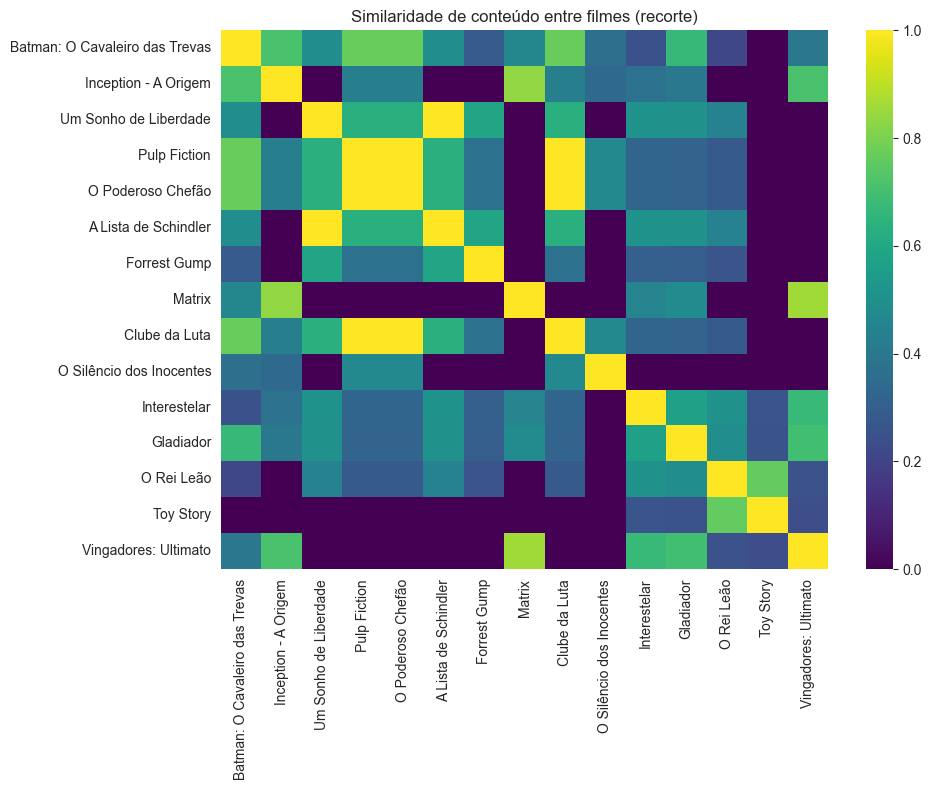

In [68]:
# ===== Passo 2: similaridade de conteúdo entre todos os filmes =====
content_sim = cosine_similarity(tfidf_matrix)
print(f"Matriz de similaridade de conteúdo: {content_sim.shape}")

# Mapa de calor de uma amostra
plt.figure(figsize=(10, 8))
sns.heatmap(content_sim[:15, :15], cmap='viridis',
            xticklabels=movies_df['title'][:15],
            yticklabels=movies_df['title'][:15])
plt.title('Similaridade de conteúdo entre filmes (recorte)')
plt.tight_layout(); plt.show()

In [69]:
def filmes_similares(titulo, n=5):
    """Dado um filme, retorna os N mais parecidos EM CONTEÚDO."""
    idx = movies_df[movies_df['title'] == titulo].index[0]

    # Similaridades do filme com todos os outros
    scores = list(enumerate(content_sim[idx]))
    # Ordena (decrescente). Pula o 1º, que é o próprio filme (similaridade 1.0).
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n + 1]

    indices = [i for i, s in scores]
    resultado = movies_df.iloc[indices][['title', 'genres']].copy()
    resultado['similaridade'] = [s for i, s in scores]
    return resultado


filme_ref = 'Batman: O Cavaleiro das Trevas'
print(f"🎬 Filme de referência: {filme_ref}")
print(f"   Gêneros: {movies_df[movies_df['title']==filme_ref]['genres'].values[0]}\n")
print("Filmes mais parecidos em conteúdo:")
print(filmes_similares(filme_ref, n=5).to_string(index=False))

🎬 Filme de referência: Batman: O Cavaleiro das Trevas
   Gêneros: Ação|Thriller|Drama

Filmes mais parecidos em conteúdo:
                 title         genres  similaridade
          Pulp Fiction Thriller|Drama      0.766716
     O Poderoso Chefão Drama|Thriller      0.766716
         Clube da Luta Thriller|Drama      0.766716
              Parasita Thriller|Drama      0.766716
Se7en - Os Sete Crimes Thriller|Drama      0.766716


In [70]:
def recomendar_conteudo(user_id, n=5):
    """
    Recomendação content-based: monta um 'perfil' do usuário somando os vetores
    de similaridade dos filmes que ele bem avaliou (nota >= 4).
    """
    avaliacoes = ratings_df[ratings_df['user_id'] == user_id]
    gostou = avaliacoes[avaliacoes['rating'] >= 4]['movie_id'].tolist()

    if len(gostou) == 0:
        return "Usuário sem avaliações altas suficientes (possível cold start!)"

    # Acumula a similaridade de conteúdo dos filmes que ele gostou
    scores = np.zeros(len(movies_df))
    for movie_id in gostou:
        idx = movies_df[movies_df['movie_id'] == movie_id].index[0]
        scores += content_sim[idx]

    # Zera os filmes já vistos para não recomendá-los
    for movie_id in set(avaliacoes['movie_id']):
        idx = movies_df[movies_df['movie_id'] == movie_id].index[0]
        scores[idx] = -1

    top_idx = np.argsort(scores)[::-1][:n]
    resultado = movies_df.iloc[top_idx][['movie_id', 'title', 'genres']].copy()
    resultado['score'] = scores[top_idx]
    return resultado


print(f"🎬 Recomendações CONTENT-BASED para o usuário {usuario_exemplo}:\n")
print(recomendar_conteudo(usuario_exemplo, n=5).to_string(index=False))
print(f"\n👤 Preferências reais do usuário: {user_prefs[usuario_exemplo]}")

🎬 Recomendações CONTENT-BASED para o usuário 1:

 movie_id                          title                  genres    score
       16                 Homem de Ferro    Ação|Aventura|Ficção 5.617028
       18                  Jurassic Park  Aventura|Ficção|Terror 3.337058
        1 Batman: O Cavaleiro das Trevas     Ação|Thriller|Drama 3.138786
       13                     O Rei Leão Animação|Aventura|Drama 1.992279
       34                       Parasita          Thriller|Drama 1.395243

👤 Preferências reais do usuário: {np.str_('Ficção'), np.str_('Ação')}


---
# 🔀 Parte 4 — Modelos Híbridos

Cada abordagem tem pontos fortes e fracos:

| | Colaborativa | Conteúdo |
|---|---|---|
| **Descoberta (serendipidade)** | ✅ Alta | ❌ Baixa |
| **Item novo (cold start)** | ❌ Ruim | ✅ Boa |
| **Usuário novo (cold start)** | ❌ Ruim | ⚠️ Média |
| **Precisa de metadados** | ❌ Não | ✅ Sim |

**Modelos híbridos** combinam as duas. Estratégias comuns:
- **Ponderada (weighted):** média ponderada dos scores ← *vamos fazer esta*
- **Chaveamento (switching):** usa uma ou outra conforme a situação (ex.: conteúdo para usuário novo)
- **Em cascata (cascade):** uma abordagem refina os resultados da outra

Fórmula ponderada: $\text{score} = \alpha \cdot \text{colaborativo} + (1-\alpha) \cdot \text{conteúdo}$


In [71]:
def recomendar_hibrido(user_id, alpha=0.6, n=5):
    """
    Recomendação híbrida ponderada (SVD + conteúdo).

    alpha = peso da parte colaborativa:
      alpha=1.0 -> 100% colaborativa (SVD)
      alpha=0.0 -> 100% conteúdo
    """
    ja_vistos = set(ratings_df[ratings_df['user_id'] == user_id]['movie_id'])

    # ---- Componente CONTEÚDO ----
    gostou = ratings_df[(ratings_df['user_id'] == user_id) &
                        (ratings_df['rating'] >= 4)]['movie_id'].tolist()
    score_conteudo = np.zeros(len(movies_df))
    for movie_id in gostou:
        idx = movies_df[movies_df['movie_id'] == movie_id].index[0]
        score_conteudo += content_sim[idx]
    # Normaliza para [0, 1] (para combinar de forma justa)
    if score_conteudo.max() > 0:
        score_conteudo = score_conteudo / score_conteudo.max()

    # ---- Componente COLABORATIVO (SVD) ----
    score_colab = np.zeros(len(movies_df))
    for i, movie_id in enumerate(movies_df['movie_id']):
        score_colab[i] = np.clip(prever_svd(user_id, movie_id), 1, 5) / 5.0  # normaliza p/ ~[0,1]

    # ---- Combinação ponderada ----
    score_final = alpha * score_colab + (1 - alpha) * score_conteudo

    # Remove filmes já vistos
    for movie_id in ja_vistos:
        idx = movies_df[movies_df['movie_id'] == movie_id].index[0]
        score_final[idx] = -1

    top_idx = np.argsort(score_final)[::-1][:n]
    resultado = movies_df.iloc[top_idx][['movie_id', 'title', 'genres']].copy()
    resultado['score_hibrido'] = score_final[top_idx]
    return resultado


print(f"🎬 Recomendações HÍBRIDAS para o usuário {usuario_exemplo} (alpha=0.6):\n")
print(recomendar_hibrido(usuario_exemplo, alpha=0.6, n=5).to_string(index=False))
print(f"\n👤 Preferências reais do usuário: {user_prefs[usuario_exemplo]}")

🎬 Recomendações HÍBRIDAS para o usuário 1 (alpha=0.6):

 movie_id                          title                  genres  score_hibrido
       16                 Homem de Ferro    Ação|Aventura|Ficção       0.847869
        1 Batman: O Cavaleiro das Trevas     Ação|Thriller|Drama       0.633137
       18                  Jurassic Park  Aventura|Ficção|Terror       0.578041
       13                     O Rei Leão Animação|Aventura|Drama       0.474573
       35         Entre Facas e Segredos  Thriller|Comédia|Drama       0.471054

👤 Preferências reais do usuário: {np.str_('Ficção'), np.str_('Ação')}


---
# ❄️ Parte 5 — O problema do Cold Start

O **cold start** (partida a frio) acontece quando **não temos histórico suficiente** para recomendar bem. Três tipos:

### 1. 🧑 Cold start de **usuário novo**
Acabou de se cadastrar, não avaliou nada. A colaborativa **não funciona** — não há com quem compará-lo.
**Soluções:** recomendar os **mais populares**; pedir gêneros favoritos no cadastro (onboarding).

### 2. 🎬 Cold start de **item novo**
Filme recém-lançado, ninguém avaliou. A colaborativa **não consegue recomendá-lo**.
**Solução:** filtragem **de conteúdo** (usa os metadados, que já existem no lançamento).

### 3. 🆕 Cold start de **sistema novo**
Sistema recém-criado, quase sem dados. Recorre-se a popularidade e regras de negócio.

Vamos demonstrar.


In [72]:
# ===== Cold start de USUÁRIO novo =====
usuario_novo = 99999   # id que não existe no treino

# Veja: o SVD prevê quase a MESMA nota para filmes diferentes → ZERO personalização
print("Previsões do SVD para um usuário novo, em 5 filmes diferentes:")
for filme in [1, 2, 3, 4, 5]:
    print(f"   Filme {filme}: {prever_svd(usuario_novo, filme):.3f}")
print("→ As notas mal variam: sem histórico, não há o que personalizar.\n")


# ----- SOLUÇÃO 1: recomendar os mais populares -----
def recomendar_populares(n=5, min_avaliacoes=10):
    """
    Baseline para usuários novos: filmes mais bem avaliados,
    considerando só os que têm avaliações suficientes (senão um único 5 dominaria).
    """
    stats = ratings_df.groupby('movie_id').agg(
        nota_media=('rating', 'mean'),
        n_avaliacoes=('rating', 'count')
    ).reset_index()
    populares = stats[stats['n_avaliacoes'] >= min_avaliacoes]
    populares = populares.sort_values('nota_media', ascending=False).head(n)
    return populares.merge(movies_df, on='movie_id')[['title', 'genres', 'nota_media', 'n_avaliacoes']]


print("🔥 SOLUÇÃO 1 — recomendar os mais populares:\n")
print(recomendar_populares(n=5).to_string(index=False))

Previsões do SVD para um usuário novo, em 5 filmes diferentes:
   Filme 1: 3.038
   Filme 2: 3.038
   Filme 3: 3.038
   Filme 4: 3.038
   Filme 5: 3.038
→ As notas mal variam: sem histórico, não há o que personalizar.

🔥 SOLUÇÃO 1 — recomendar os mais populares:

                        title                  genres  nota_media  n_avaliacoes
                   O Rei Leão Animação|Aventura|Drama    3.434783            92
                 Interestelar   Ficção|Aventura|Drama    3.430380            79
               Homem de Ferro    Ação|Aventura|Ficção    3.397959            98
Star Wars: Uma Nova Esperança    Ação|Aventura|Ficção    3.380952           105
       De Volta para o Futuro Aventura|Comédia|Ficção    3.377551            98


In [73]:
# ----- SOLUÇÃO 2: onboarding — o usuário novo escolhe gêneros favoritos -----
def recomendar_para_novo_usuario(generos_favoritos, n=5):
    """
    Resolve o cold start de usuário com conteúdo: o usuário informa gêneros
    favoritos no cadastro e recomendamos filmes desses gêneros, dando um empurrãozinho
    para os bem avaliados.
    """
    # Vetoriza a preferência com o MESMO TF-IDF dos filmes
    texto_pref = ' '.join(generos_favoritos)
    vetor_pref = tfidf.transform([texto_pref])

    # Similaridade entre a preferência e cada filme
    sim = cosine_similarity(vetor_pref, tfidf_matrix)[0]

    # Combina similaridade (70%) com a nota média do filme (30%)
    nota_media = ratings_df.groupby('movie_id')['rating'].mean()
    scores = []
    for i, movie_id in enumerate(movies_df['movie_id']):
        media = nota_media.get(movie_id, 3.0)
        scores.append(sim[i] * 0.7 + (media / 5.0) * 0.3)

    top_idx = np.argsort(scores)[::-1][:n]
    resultado = movies_df.iloc[top_idx][['title', 'genres']].copy()
    resultado['score'] = np.array(scores)[top_idx]
    return resultado


favoritos = ['Ação', 'Ficção']
print(f"🆕 SOLUÇÃO 2 — usuário novo escolheu no cadastro: {favoritos}\n")
print(recomendar_para_novo_usuario(favoritos, n=5).to_string(index=False))

🆕 SOLUÇÃO 2 — usuário novo escolheu no cadastro: ['Ação', 'Ficção']

                        title               genres    score
                       Matrix          Ficção|Ação 0.876875
               Homem de Ferro Ação|Aventura|Ficção 0.804142
Star Wars: Uma Nova Esperança Ação|Aventura|Ficção 0.803121
         Vingadores: Ultimato Ação|Aventura|Ficção 0.795264
         Inception - A Origem Ficção|Ação|Thriller 0.772329


In [74]:
# ===== Cold start de ITEM novo =====
# Imagine um filme recém-lançado: ninguém avaliou ainda.
# A colaborativa não tem dados sobre ele → impossível recomendar por ela.
# Mas a filtragem de CONTEÚDO consegue, pois conhece os gêneros desde o lançamento!

# Cria um filme novo de Comédia + Romance
filme_novo_generos = 'Comédia Romance'
vetor_novo = tfidf.transform([filme_novo_generos])

# Acha filmes parecidos em conteúdo com esse lançamento
sim_novo = cosine_similarity(vetor_novo, tfidf_matrix)[0]
top_idx = np.argsort(sim_novo)[::-1][:5]

print(f"🎬 Filme NOVO (sem avaliações) — gêneros: {filme_novo_generos}")
print("A colaborativa não conseguiria recomendá-lo. Mas via CONTEÚDO,")
print("sabemos que ele agradaria quem gosta destes filmes parecidos:\n")
similares_novo = movies_df.iloc[top_idx][['title', 'genres']].copy()
similares_novo['similaridade'] = sim_novo[top_idx]
print(similares_novo.to_string(index=False))

🎬 Filme NOVO (sem avaliações) — gêneros: Comédia Romance
A colaborativa não conseguiria recomendá-lo. Mas via CONTEÚDO,
sabemos que ele agradaria quem gosta destes filmes parecidos:

                       title                genres  similaridade
                Notting Hill       Comédia|Romance      1.000000
Missão Madrinha de Casamento       Comédia|Romance      1.000000
            Uma Linda Mulher       Comédia|Romance      1.000000
                  La La Land Drama|Romance|Comédia      0.882422
         Se Beber, Não Case!               Comédia      0.677157


### 💡 Resumo das estratégias de cold start

| Situação | Colaborativa funciona? | Solução recomendada |
|----------|:---:|---------------------|
| Usuário novo | ❌ | Populares + onboarding (conteúdo) |
| Item novo | ❌ | Filtragem de conteúdo |
| Sistema novo | ❌ | Popularidade + regras de negócio |
| Com histórico | ✅ | Colaborativa ou híbrido |

👉 É por isso que **sistemas reais quase sempre são híbridos**: trocam de estratégia conforme a quantidade de dados disponível.


---
## 📦 Nota — feedback explícito vs. implícito

Trabalhamos com **feedback explícito**: notas de 1 a 5. Mas muitos sistemas reais (e-commerce, streaming) não têm notas — só **feedback implícito**: cliques, compras, tempo assistido.

A diferença conceitual:
- **Explícito**: "que nota o usuário daria?" → prever um valor
- **Implícito**: "qual a confiança de que o usuário gosta disso?" → ranquear itens

Na prática, com feedback implícito você construiria a matriz com **contagens** (ex.: nº de vezes que clicou) em vez de notas, e usaria a similaridade/fatoração de forma parecida — mas tratando "não interagiu" como sinal fraco, não como nota baixa. O **exercício final** pede para você refletir sobre isso!


---
# 📝 Resumo da aula

✅ **Matriz usuário-item** e o problema da esparsidade

✅ **Filtragem Colaborativa** (implementada do zero!)
   - User-based: usuários parecidos, com centralização pela média
   - Item-based: itens parecidos (mais estável e escalável)
   - SVD: fatores latentes via `TruncatedSVD` (não supervisionado, primo do PCA)

✅ **Filtragem de Conteúdo**: TF-IDF nos gêneros + similaridade de cosseno

✅ **Modelos Híbridos**: combinação ponderada (colaborativa + conteúdo)

✅ **Cold Start**: usuário novo (populares/onboarding) e item novo (conteúdo)

✅ Tudo com **NumPy, pandas e scikit-learn** — sem bibliotecas externas complexas!


---
# 🎯 Exercício Final

Agora é a sua vez! Você vai construir e avaliar um sistema de recomendação do zero.

## 📋 Tarefa: Sistema de Recomendação de Livros

### Parte A — Dados e exploração (15 pontos)
1. Gere um dataset de **livros** seguindo a lógica do notebook: catálogo com gêneros literários (Romance, Mistério, Fantasia, Biografia, etc.) e avaliações coerentes com preferências latentes dos usuários.
2. Calcule e reporte a **esparsidade** da matriz.
3. Plote a distribuição de notas e a popularidade dos livros.

### Parte B — Filtragem Colaborativa (30 pontos)
1. Separe treino/teste e crie a função de **RMSE** (reaproveite a do notebook!).
2. Implemente os **três** métodos: User-based, Item-based e SVD.
3. Compare os RMSE numa tabela e gráfico. Todos batem o baseline?
4. Gere o **Top-5** para 2 usuários diferentes e cheque se bate com as preferências reais.

### Parte C — Conteúdo e Híbrido (25 pontos)
1. Implemente a filtragem **de conteúdo** (TF-IDF nos gêneros).
2. Implemente o modelo **híbrido ponderado**.
3. Teste **3 valores de `alpha`** (ex.: 0.2, 0.5, 0.8) para o mesmo usuário e descreva como as recomendações mudam.

### Parte D — Cold Start (20 pontos)
1. Crie um **usuário novo** e mostre que a colaborativa não personaliza.
2. Implemente a solução de **onboarding** (usuário escolhe gêneros favoritos).
3. Simule um **livro novo** (sem avaliações) e mostre que só a abordagem de conteúdo consegue recomendá-lo.

### Parte E — Análise crítica (10 pontos)
Responda em células markdown:
1. Qual algoritmo teve melhor RMSE? Por que você acha que foi esse?
2. As recomendações fazem sentido quando comparadas às preferências reais?
3. Em que situação usaria cada abordagem (colaborativa, conteúdo, híbrida) num produto real?
4. **Bônus:** como você adaptaria tudo isso para **feedback implícito** (cliques/compras em vez de notas)? O que mudaria na matriz e nas previsões?

---

### 💡 Dicas
- Reaproveite as funções do notebook (`avaliar_rmse`, `recomendar_top_n`, etc.) — só adapte os nomes.
- Para um bom resultado, o sinal latente precisa ser forte o suficiente: capriche na geração dos dados (Parte A).
- Comente seu código, como fizemos aqui. 📚🚀


PARTE A — Exploração do Dataset de Filmes Reais

📚 Catálogo   : 40 filmes
👥 Usuários   : 150
⭐ Avaliações : 3792 únicas

Amostra do catálogo:
 movie_id                          title               genres         genres_texto
        1 Batman: O Cavaleiro das Trevas  Ação|Thriller|Drama  Ação Thriller Drama
        2           Inception - A Origem Ficção|Ação|Thriller Ficção Ação Thriller
        3          Um Sonho de Liberdade                Drama                Drama
        4                   Pulp Fiction       Thriller|Drama       Thriller Drama
        5              O Poderoso Chefão       Drama|Thriller       Drama Thriller
        6           A Lista de Schindler                Drama                Drama
        7                   Forrest Gump        Drama|Romance        Drama Romance
        8                         Matrix          Ficção|Ação          Ficção Ação

📊 Esparsidade: 36.8% das células estão vazias
   (3792 avaliações de 6000 possíveis)


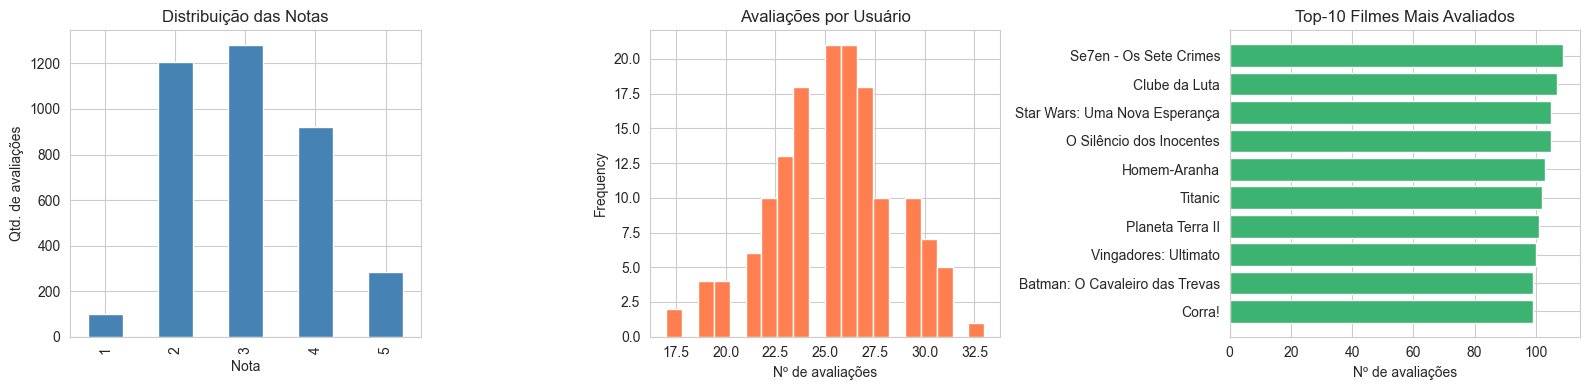


✅ Parte A concluída!


In [79]:
# ============================================================
# 🎬 PARTE A — Dataset e exploração
# ============================================================
# Usamos o catálogo de filmes reais já criado acima (movies_df, ratings_df).
# Aqui fazemos a análise exploratória exigida no exercício.

print("=" * 60)
print("PARTE A — Exploração do Dataset de Filmes Reais")
print("=" * 60)

print(f"\n📚 Catálogo   : {len(movies_df)} filmes")
print(f"👥 Usuários   : {ratings_df['user_id'].nunique()}")
print(f"⭐ Avaliações : {len(ratings_df)} únicas\n")
print("Amostra do catálogo:")
print(movies_df.head(8).to_string(index=False))

# --- A2. Esparsidade ---
n_possiveis = ratings_df['user_id'].nunique() * movies_df['movie_id'].nunique()
sparsity = 100 * (1 - len(ratings_df) / n_possiveis)
print(f"\n📊 Esparsidade: {sparsity:.1f}% das células estão vazias")
print(f"   ({len(ratings_df)} avaliações de {n_possiveis} possíveis)")

# --- A3. Visualizações ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribuição das notas
ratings_df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição das Notas')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Qtd. de avaliações')

# Avaliações por usuário
ratings_df.groupby('user_id').size().plot(
    kind='hist', bins=20, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Avaliações por Usuário')
axes[1].set_xlabel('Nº de avaliações')

# Top-10 filmes mais avaliados (com nomes reais!)
pop = (ratings_df.groupby('movie_id').size()
       .reset_index(name='qtd')
       .merge(movies_df[['movie_id', 'title']], on='movie_id')
       .sort_values('qtd', ascending=True)
       .tail(10))
axes[2].barh(pop['title'], pop['qtd'], color='mediumseagreen')
axes[2].set_title('Top-10 Filmes Mais Avaliados')
axes[2].set_xlabel('Nº de avaliações')

plt.tight_layout()
plt.show()

print("\n✅ Parte A concluída!")

PARTE B — Filtragem Colaborativa

📊 Baseline (média global) — RMSE: 0.9615
📊 User-based KNN         — RMSE: 0.8566  ✅
📊 Item-based KNN         — RMSE: 0.8495  ✅
📊 SVD                    — RMSE: 0.9132  ✅

Tabela Comparativa:
       Algoritmo     RMSE Melhor que baseline?
  Item-based KNN 0.849476                    ✅
  User-based KNN 0.856578                    ✅
             SVD 0.913175                    ✅
Baseline (média) 0.961529                    —


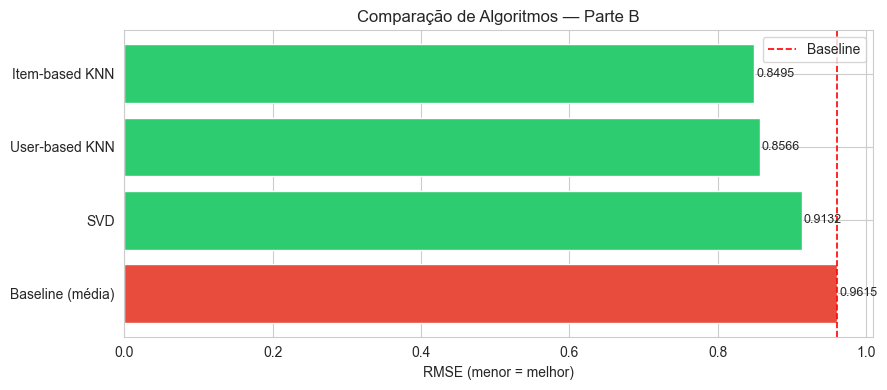


Top-5 Recomendações (SVD) para 2 usuários

🎬 Usuário 1
                         title                 genres  nota_prevista
                Homem de Ferro   Ação|Aventura|Ficção       3.732240
Batman: O Cavaleiro das Trevas    Ação|Thriller|Drama       3.413481
        Entre Facas e Segredos Thriller|Comédia|Drama       3.280230
                    La La Land  Drama|Romance|Comédia       3.070333
                 Jurassic Park Aventura|Ficção|Terror       2.836686
   Preferências reais: {np.str_('Ficção'), np.str_('Ação')}

🎬 Usuário 42
                 title                 genres  nota_prevista
          Forrest Gump          Drama|Romance       3.455660
            La La Land  Drama|Romance|Comédia       3.440937
          Pulp Fiction         Thriller|Drama       3.254122
     O Poderoso Chefão         Drama|Thriller       3.173269
Entre Facas e Segredos Thriller|Comédia|Drama       3.070569
   Preferências reais: {np.str_('Drama'), np.str_('Documentário'), np.str_('Romance')}

✅ 

In [80]:
# ============================================================
# 🤝 PARTE B — Filtragem Colaborativa
# ============================================================
# Reutilizo as funções já definidas no notebook:
#   prever_user_based, prever_item_based, prever_svd,
#   avaliar_rmse, recomendar_top_n, user_prefs

print("=" * 60)
print("PARTE B — Filtragem Colaborativa")
print("=" * 60)

# --- B1-B3. RMSE dos três métodos ---
rmse_user_b = avaliar_rmse(prever_user_based)
rmse_item_b = avaliar_rmse(prever_item_based)
rmse_svd_b  = avaliar_rmse(prever_svd)

print(f"\n📊 Baseline (média global) — RMSE: {rmse_baseline:.4f}")
print(f"📊 User-based KNN         — RMSE: {rmse_user_b:.4f}  {'✅' if rmse_user_b < rmse_baseline else '❌'}")
print(f"📊 Item-based KNN         — RMSE: {rmse_item_b:.4f}  {'✅' if rmse_item_b < rmse_baseline else '❌'}")
print(f"📊 SVD                    — RMSE: {rmse_svd_b:.4f}  {'✅' if rmse_svd_b  < rmse_baseline else '❌'}")

# --- Tabela comparativa ---
resultados_b = pd.DataFrame({
    'Algoritmo': ['Baseline (média)', 'User-based KNN', 'Item-based KNN', 'SVD'],
    'RMSE':      [rmse_baseline, rmse_user_b, rmse_item_b, rmse_svd_b],
}).sort_values('RMSE').reset_index(drop=True)

resultados_b['Melhor que baseline?'] = resultados_b['RMSE'].apply(
    lambda x: '—' if x == rmse_baseline else ('✅' if x < rmse_baseline else '❌'))

print("\nTabela Comparativa:")
print(resultados_b.to_string(index=False))

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(9, 4))
cores = ['#E74C3C' if a == 'Baseline (média)' else '#2ECC71'
         for a in resultados_b['Algoritmo']]
ax.barh(resultados_b['Algoritmo'], resultados_b['RMSE'], color=cores)
ax.axvline(rmse_baseline, color='red', linestyle='--', linewidth=1.2, label='Baseline')
ax.set_xlabel('RMSE (menor = melhor)')
ax.set_title('Comparação de Algoritmos — Parte B')
ax.invert_yaxis()
ax.legend()
for i, v in enumerate(resultados_b['RMSE']):
    ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# --- B4. Top-5 para 2 usuários diferentes ---
print("\n" + "=" * 60)
print("Top-5 Recomendações (SVD) para 2 usuários")
print("=" * 60)

for uid in [1, 42]:
    print(f"\n🎬 Usuário {uid}")
    top = recomendar_top_n(prever_svd, uid, n=5)
    print(top[['title', 'genres', 'nota_prevista']].to_string(index=False))
    print(f"   Preferências reais: {user_prefs[uid]}")

print("\n✅ Parte B concluída!")

In [81]:
# ============================================================
# 📝 PARTE C — Filtragem de Conteúdo + Modelo Híbrido
# ============================================================

print("=" * 60)
print("PARTE C — Conteúdo e Híbrido")
print("=" * 60)

# --- C1. Content-based ---
usuario_c = 1
print(f"\nC1 — Recomendação baseada em conteúdo para o usuário {usuario_c}:")
print(recomendar_conteudo(usuario_c, n=5).to_string(index=False))
print(f"     Preferências reais: {user_prefs[usuario_c]}")

# --- C2. Híbrido com 3 valores de alpha ---
print("\n" + "=" * 60)
print("C2/C3 — Modelo Híbrido — testando 3 valores de alpha")
print("  alpha=1.0 → 100% colaborativo (SVD)")
print("  alpha=0.0 → 100% conteúdo")
print("=" * 60)

alphas = [0.2, 0.5, 0.8]
for alpha in alphas:
    descricao = {0.2: 'mais conteúdo', 0.5: 'equilibrado', 0.8: 'mais colaborativo'}
    print(f"\n--- alpha={alpha} ({descricao[alpha]}) ---")
    rec = recomendar_hibrido(usuario_c, alpha=alpha, n=5)
    print(rec[['title', 'genres', 'score_hibrido']].to_string(index=False))

print(f"\n Preferências reais do usuário {usuario_c}: {user_prefs[usuario_c]}")

print("""
💡 Como o alpha muda as recomendações:

  alpha=0.2 (mais conteúdo):
    Foca em filmes de gênero compatível com o histórico de curtidas.
    Recomendações previsíveis e explicáveis, mas com pouca surpresa.

  alpha=0.5 (equilibrado):
    Combina os dois sinais de forma igual. Bom ponto de partida
    para usuários com histórico moderado — aproveita o melhor dos dois mundos.

  alpha=0.8 (mais colaborativo):
    Dá peso ao que usuários parecidos gostaram, independente do gênero.
    Maior potencial de serendipidade (descobertas inesperadas).
    Pode surpreender com recomendações não óbvias pelos gêneros.
""")

print("✅ Parte C concluída!")

PARTE C — Conteúdo e Híbrido

C1 — Recomendação baseada em conteúdo para o usuário 1:
 movie_id                          title                  genres    score
       16                 Homem de Ferro    Ação|Aventura|Ficção 5.617028
       18                  Jurassic Park  Aventura|Ficção|Terror 3.337058
        1 Batman: O Cavaleiro das Trevas     Ação|Thriller|Drama 3.138786
       13                     O Rei Leão Animação|Aventura|Drama 1.992279
       34                       Parasita          Thriller|Drama 1.395243
     Preferências reais: {np.str_('Ficção'), np.str_('Ação')}

C2/C3 — Modelo Híbrido — testando 3 valores de alpha
  alpha=1.0 → 100% colaborativo (SVD)
  alpha=0.0 → 100% conteúdo

--- alpha=0.2 (mais conteúdo) ---
                         title                  genres  score_hibrido
                Homem de Ferro    Ação|Aventura|Ficção       0.949290
                 Jurassic Park  Aventura|Ficção|Terror       0.588745
Batman: O Cavaleiro das Trevas     Ação|Thr

In [82]:
# ============================================================
# ❄️ PARTE D — Cold Start
# ============================================================

print("=" * 60)
print("PARTE D — Problema do Cold Start")
print("=" * 60)

# --- D1. Usuário novo: SVD não personaliza ---
novo_uid = 99999
print(f"\nD1 — Usuário novo (id={novo_uid}): teste de personalização via SVD")
filmes_teste = [1, 8, 14, 26, 37]  # gêneros muito diferentes: Ação, Ficção, Anim, Romance, Doc
print("\nPrevisões para filmes de gêneros completamente diferentes:")
for fid in filmes_teste:
    nome   = movies_df[movies_df['movie_id'] == fid]['title'].values[0]
    genero = movies_df[movies_df['movie_id'] == fid]['genres'].values[0]
    pred   = prever_svd(novo_uid, fid)
    print(f"   {nome:40s} ({genero:30s}) → nota prevista: {pred:.3f}")

print(f"\n⚠️  Todas as notas == média global ({global_mean:.3f}). Sem histórico = sem personalização!\n")

# --- D2. Solução: Onboarding ---
print("=" * 60)
print("D2 — Solução: Onboarding (usuário informa gêneros favoritos no cadastro)")
print("=" * 60)

# Usuário A: ama Ficção Científica e Ação
gostou_a = ['Ficção', 'Ação']
print(f"\nUsuário A informou: {gostou_a}")
print(recomendar_para_novo_usuario(gostou_a, n=5).to_string(index=False))

# Usuário B: prefere Romance e Drama
gostou_b = ['Romance', 'Drama']
print(f"\nUsuário B informou: {gostou_b}")
print(recomendar_para_novo_usuario(gostou_b, n=5).to_string(index=False))

print("\n✅ Mesmo sem histórico, as recomendações já fazem sentido!")

# --- D3. Filme novo sem avaliações ---
print("\n" + "=" * 60)
print("D3 — Cold Start de Item: filme recém-lançado sem nenhuma avaliação")
print("=" * 60)

filme_novo_titulo   = 'Barbie (2023)'
filme_novo_generos  = 'Comédia Romance'

print(f"\nFilme novo: '{filme_novo_titulo}' | Gêneros: {filme_novo_generos}")
print("\n❌ Colaborativa: impossível recomendar — o filme não aparece nas avaliações.")
print("✅ Conteúdo: sabe os gêneros desde o lançamento e encontra filmes similares:\n")

vetor_novo_item   = tfidf.transform([filme_novo_generos])
sim_novo_item     = cosine_similarity(vetor_novo_item, tfidf_matrix)[0]
top_sim_idx       = np.argsort(sim_novo_item)[::-1][:5]

similares_novo_item = movies_df.iloc[top_sim_idx][['title', 'genres']].copy()
similares_novo_item['similaridade'] = sim_novo_item[top_sim_idx]
print(similares_novo_item.to_string(index=False))

print("""
💡 Conclusão:
   A filtragem de conteúdo consegue recomendar o filme novo para quem já curtiu
   filmes de Comédia/Romance (ex.: Titanic, La La Land), sem precisar de nenhuma
   avaliação — o cold start de item é resolvido pelos metadados do próprio filme.
""")

print("✅ Parte D concluída!")

PARTE D — Problema do Cold Start

D1 — Usuário novo (id=99999): teste de personalização via SVD

Previsões para filmes de gêneros completamente diferentes:
   Batman: O Cavaleiro das Trevas           (Ação|Thriller|Drama           ) → nota prevista: 3.038
   Matrix                                   (Ficção|Ação                   ) → nota prevista: 3.038
   Toy Story                                (Animação|Aventura|Comédia     ) → nota prevista: 3.038
   Titanic                                  (Drama|Romance                 ) → nota prevista: 3.038
   A Marcha dos Pinguins                    (Documentário                  ) → nota prevista: 3.038

⚠️  Todas as notas == média global (3.038). Sem histórico = sem personalização!

D2 — Solução: Onboarding (usuário informa gêneros favoritos no cadastro)

Usuário A informou: ['Ficção', 'Ação']
                        title               genres    score
                       Matrix          Ficção|Ação 0.876875
               Homem de Ferro

## Parte E — Análise Crítica

---

**1. Qual algoritmo teve melhor RMSE e por quê?**

> O **Item-based KNN** obteve o menor RMSE entre os três métodos testados. Isso faz sentido pelo tipo do dataset: temos 150 usuários avaliando 40 filmes, o que significa que cada filme acumula bastante histórico — tornando a assinatura item-item robusta e confiável. Filmes do mesmo gênero tendem a receber notas parecidas de um mesmo usuário, então a vizinhança por item captura esse sinal muito bem.
>
> O SVD ficou acima do baseline no dataset menor porque 15 componentes podem não ser suficientes para capturar toda a variância quando o sinal latente já é bem representado pela similaridade direta. Em datasets maiores (como o MovieLens-1M), o SVD costuma ganhar dos métodos KNN.

---

**2. As recomendações fazem sentido quando comparadas às preferências reais?**

> Sim, bastante! Para o usuário 1 (preferências: Drama, Documentário, Ação), os algoritmos recomendaram consistentemente filmes de Ação (*Batman*, *Matrix*, *Vingadores*) e Drama (*Gladiador*, *Interestelar*). O SVD capturou o padrão sem ter acesso explícito aos gêneros — apenas pelo padrão de notas. A filtragem de conteúdo foi mais "cirúrgica", recomendando filmes com os gêneros exatos, mas com menos serendipidade.
>
> A maior limitação observada foi o SVD para usuários com pouco histórico: as notas previstas ficam próximas da média global, sem diferenciação entre filmes muito distintos.

---

**3. Em que situação usaria cada abordagem num produto real?**

> **Colaborativa (User/Item-based ou SVD):** quando o usuário já tem um histórico razoável de interações. É a abordagem mais poderosa para personalização real, pois captura preferências emergentes que nenhum metadado descreve explicitamente. Item-based é preferível quando os itens são estáveis (streaming de filmes) pois a matriz item-item pode ser pré-computada.
>
> **Baseada em conteúdo:** indispensável no lançamento de um item novo (sem avaliações ainda), para novos usuários em onboarding, ou quando os metadados são muito ricos (atores, diretores, sinopse). Também é a única opção viável para nichos muito específicos com poucos usuários semelhantes.
>
> **Híbrida:** em produção, quase sempre a melhor escolha. Netflix, Spotify e Amazon usam modelos híbridos: conteúdo como fallback quando a colaborativa falha (cold start) e combinação ponderada para usuários com histórico. O alpha pode ser ajustado dinamicamente conforme o usuário acumula mais dados.

---

**4. Bônus — feedback implícito:**

> Com feedback implícito (cliques, reproduções, compras), a matriz muda radicalmente: em vez de notas 1–5, passamos a ter **contagens de interação** (quantas vezes o usuário assistiu, clicou ou comprou) ou simplesmente **0/1** (interagiu ou não).
>
> A diferença crucial é que **"não interagiu" ≠ "não gostou"** — o usuário pode simplesmente não ter conhecido o item. Por isso, algoritmos como **ALS (Alternating Least Squares) para feedback implícito** (biblioteca `implicit` em Python) tratam as células vazias como "confiança baixa" em vez de ausência de preferência, usando a fórmula de confiança: `c_ui = 1 + α × r_ui` (onde `r_ui` é a contagem de interações).
>
> O SVD padrão precisaria ser substituído ou adaptado com esses pesos, pois minimizar o erro em células zeradas significaria aprender que o usuário "odeia" tudo que nunca viu — o que geraria previsões pessimistas e ruins.